# Notebook 12 - Feature Family Ablation Matrix

This notebook runs a full ablation matrix for temperature prediction using your three strongest model choices:

- `voting` (NB11 leader)
- `gradient_boosting` (NB10 recommended baseline)
- `xgboost` (strong random-split performer)

Feature families tested:

- `physical_only`
- `chemical_only`
- `ratios_only`
- `combined_all`

Protocols:

- `random_split` (10 seeds)
- `groupkfold` (5 folds by `State`)
- `spatial_holdout` (leave-one-state-out, groups with >=30 samples)

All findings are exported with both RMSE and R2.

In [1]:
## DO NOT CHANGE

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, VotingRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def detect_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'scripts').exists() and (candidate / 'README.md').exists():
            return candidate
    raise FileNotFoundError('Could not auto-detect project root from notebook location.')

PROJECT_ROOT = detect_project_root(Path.cwd())
PHD_OS_ROOT = PROJECT_ROOT.parents[1]
NOTEBOOK_ROOT = PROJECT_ROOT / 'manual_bootstrap' / 'step_by_step_notebooks' / '12_ablation_feature_families_no_scripts'
OUTPUT_ROOT = NOTEBOOK_ROOT / 'outputs'
SUMMARY_TABLE_ROOT = OUTPUT_ROOT / 'summary' / 'tables'
SUMMARY_FIG_ROOT = OUTPUT_ROOT / 'summary' / 'figures'
SUMMARY_REPORT_ROOT = OUTPUT_ROOT / 'summary' / 'reports'
for p in [SUMMARY_TABLE_ROOT, SUMMARY_FIG_ROOT, SUMMARY_REPORT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

data_candidates = [
    PHD_OS_ROOT / '03_data_processed' / 'geothermal_canonical_v2_0_0.csv',
    PROJECT_ROOT / 'data' / '03_processed' / 'geothermal_canonical_v2_0_0.csv',
    PROJECT_ROOT / 'manual_bootstrap' / 'phd-geothermal-ml_mirror' / '03_data_processed' / 'geothermal_canonical_v2_0_0.csv'
]
data_path = None
for p in data_candidates:
    if p.exists():
        data_path = p
        break
if data_path is None:
    raise FileNotFoundError('No geothermal canonical CSV found in candidate paths.')

raw_df = pd.read_csv(data_path)
# Avoid carrying legacy ratio columns from previous experiments.
raw_df = raw_df.drop(columns=[c for c in raw_df.columns if c.startswith('ratio_')], errors='ignore')
df = raw_df.copy()

TARGET = 'Temperature(C)'
GROUP_COL = 'State' if 'State' in df.columns else None

drop_cols = [TARGET]
if GROUP_COL is not None:
    drop_cols.append(GROUP_COL)

base_numeric_cols = [c for c in df.columns if c not in drop_cols and pd.api.types.is_numeric_dtype(df[c])]
phys_keywords = ['depth', 'elev', 'latitude', 'longitude']
phys_cols = [c for c in base_numeric_cols if any(k in c.lower() for k in phys_keywords)]
chem_numeric_cols = [c for c in base_numeric_cols if c not in phys_cols]

# Curated hydrochemical ratio set (domain-driven) instead of broad pairwise ratios.
curated_ratio_pairs = [
    ('Na', 'K'), ('Na', 'Ca'), ('Na', 'Mg'), ('Na', 'Cl'),
    ('Ca', 'Mg'), ('Ca', 'SO4'), ('K', 'Mg'),
    ('Cl', 'HCO3'), ('HCO3', 'Cl'), ('Cl', 'SO4'), ('SO4', 'Cl'),
    ('TDS', 'Cl'), ('SiO2', 'Cl'), ('Li', 'Cl'), ('B', 'Cl'), ('Br', 'Cl'),
    ('F', 'Cl'), ('As', 'Cl'), ('Fe', 'Mn'), ('pH', 'TDS')
]

eps = 1e-6
ratio_cols_created = []
for num_col, den_col in curated_ratio_pairs:
    if num_col not in df.columns or den_col not in df.columns:
        continue
    ratio_name = f'ratio_{num_col}_to_{den_col}'
    denom = df[den_col].replace(0, np.nan)
    ratio_series = df[num_col] / (denom + eps)
    ratio_series = ratio_series.replace([np.inf, -np.inf], np.nan)

    if ratio_series.notna().sum() < int(0.3 * len(df)):
        continue

    df[ratio_name] = ratio_series  # raw; winsorization applied per-split in prepare_design_matrix
    ratio_cols_created.append(ratio_name)

feature_map = {
    'physical_only': [c for c in phys_cols if c in df.columns],
    'chemical_only': [c for c in chem_numeric_cols if c in df.columns],
    'ratios_only': ratio_cols_created,
}
feature_map['combined_all'] = [c for c in df.columns if c not in drop_cols]

print('Using dataset:', data_path)
print('Shape (after curated ratios):', df.shape)
print('Curated ratio features generated:', len(ratio_cols_created))
for k, v in feature_map.items():
    print(f'{k}: {len(v)} features')

weights = {'random_split': 0.2, 'groupkfold': 0.4, 'spatial_holdout': 0.4}
run_seeds = list(range(10))

Using dataset: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\03_data_processed\geothermal_canonical_v2_0_0.csv
Shape (after curated ratios): (2684, 34)
Curated ratio features generated: 12
physical_only: 3 features
chemical_only: 17 features
ratios_only: 12 features
combined_all: 32 features


In [3]:
def prepare_design_matrix(train_df: pd.DataFrame, test_df: pd.DataFrame):
    cat_cols = train_df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    num_cols = [c for c in train_df.columns if c not in cat_cols]

    train_enc = pd.get_dummies(train_df, columns=cat_cols, drop_first=False)
    test_enc = pd.get_dummies(test_df, columns=cat_cols, drop_first=False)
    test_enc = test_enc.reindex(columns=train_enc.columns, fill_value=0)

    if len(num_cols) > 0:
        imputer = SimpleImputer(strategy='median')
        train_enc[num_cols] = imputer.fit_transform(train_enc[num_cols])
        test_enc[num_cols] = imputer.transform(test_enc[num_cols])

    # Winsorize ratio columns using training-set bounds (fix: no pre-split leakage)
    for col in [c for c in train_enc.columns if c.startswith('ratio_')]:
        lo = train_enc[col].quantile(0.01)
        hi = train_enc[col].quantile(0.99)
        train_enc[col] = train_enc[col].clip(lo, hi)
        test_enc[col] = test_enc[col].clip(lo, hi)

    return train_enc, test_enc


def model_factory():
    gbm = GradientBoostingRegressor(n_estimators=350, learning_rate=0.05, max_depth=3, random_state=42)
    xgb = XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=7, subsample=0.85, colsample_bytree=0.85, random_state=42, n_jobs=-1)
    et = ExtraTreesRegressor(n_estimators=400, max_depth=None, min_samples_leaf=1, n_jobs=-1, random_state=42)

    return {
        'gradient_boosting': gbm,
        'xgboost': xgb,
        'voting': VotingRegressor(estimators=[
            ('gbm', GradientBoostingRegressor(n_estimators=350, learning_rate=0.05, max_depth=3, random_state=42)),
            ('xgb', XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=7, subsample=0.85, colsample_bytree=0.85, random_state=42, n_jobs=-1)),
            ('et', ExtraTreesRegressor(n_estimators=400, max_depth=None, min_samples_leaf=1, n_jobs=-1, random_state=42))
        ])
    }


rows = []
eligible_groups = df[GROUP_COL].value_counts()
eligible_groups = eligible_groups[eligible_groups >= 30].index.tolist() if GROUP_COL else ['ALL']

for feature_family, cols in feature_map.items():
    if len(cols) == 0:
        print(f'Skipping {feature_family}: no columns detected')
        continue

    X_raw = df[cols].copy()
    y_all = df[TARGET].copy()
    groups_all = df[GROUP_COL].copy() if GROUP_COL else pd.Series(['ALL'] * len(df), index=df.index)

    # random_split
    for seed in run_seeds:
        X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y_all, test_size=0.2, random_state=seed)
        X_train, X_test = prepare_design_matrix(X_train_raw, X_test_raw)

        for model_name, model in model_factory().items():
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            rows.append({
                'feature_family': feature_family,
                'model_name': model_name,
                'protocol': 'random_split',
                'seed': seed,
                'holdout_group': 'NA',
                'n_features': len(cols),
                'n_train': len(X_train),
                'n_test': len(X_test),
                'mae': mean_absolute_error(y_test, pred),
                'rmse': np.sqrt(mean_squared_error(y_test, pred)),
                'r2': r2_score(y_test, pred)
            })

    # groupkfold
    gkf = GroupKFold(n_splits=5)
    for fold_idx, (tr_idx, te_idx) in enumerate(gkf.split(X_raw, y_all, groups_all), start=1):
        X_tr_raw, X_te_raw = X_raw.iloc[tr_idx], X_raw.iloc[te_idx]
        y_tr, y_te = y_all.iloc[tr_idx], y_all.iloc[te_idx]
        X_tr, X_te = prepare_design_matrix(X_tr_raw, X_te_raw)

        for model_name, model in model_factory().items():
            model.fit(X_tr, y_tr)
            pred = model.predict(X_te)
            rows.append({
                'feature_family': feature_family,
                'model_name': model_name,
                'protocol': 'groupkfold',
                'seed': 42,
                'holdout_group': f'fold_{fold_idx}',
                'n_features': len(cols),
                'n_train': len(X_tr),
                'n_test': len(X_te),
                'mae': mean_absolute_error(y_te, pred),
                'rmse': np.sqrt(mean_squared_error(y_te, pred)),
                'r2': r2_score(y_te, pred)
            })

    # spatial_holdout
    for g in eligible_groups:
        te_idx = groups_all[groups_all == g].index
        tr_idx = groups_all[groups_all != g].index

        X_tr_raw, X_te_raw = X_raw.loc[tr_idx], X_raw.loc[te_idx]
        y_tr, y_te = y_all.loc[tr_idx], y_all.loc[te_idx]
        X_tr, X_te = prepare_design_matrix(X_tr_raw, X_te_raw)

        for model_name, model in model_factory().items():
            model.fit(X_tr, y_tr)
            pred = model.predict(X_te)
            rows.append({
                'feature_family': feature_family,
                'model_name': model_name,
                'protocol': 'spatial_holdout',
                'seed': 42,
                'holdout_group': str(g),
                'n_features': len(cols),
                'n_train': len(X_tr),
                'n_test': len(X_te),
                'mae': mean_absolute_error(y_te, pred),
                'rmse': np.sqrt(mean_squared_error(y_te, pred)),
                'r2': r2_score(y_te, pred)
            })

    print(f'Completed family: {feature_family}')

runs_df = pd.DataFrame(rows)
summary = (
    runs_df.groupby(['feature_family', 'model_name', 'protocol'])[['mae', 'rmse', 'r2']]
    .mean()
    .reset_index()
)

ranked = summary.copy()
ranked['protocol_rank'] = ranked.groupby(['feature_family', 'protocol'])['rmse'].rank(method='dense', ascending=True)
ranked['weight'] = ranked['protocol'].map(weights)
ranked['weighted_score'] = ranked['protocol_rank'] * ranked['weight']

leaderboard = (
    ranked.groupby(['feature_family', 'model_name'])['weighted_score']
    .sum()
    .reset_index()
    .sort_values(['feature_family', 'weighted_score'])
)

best_per_family = leaderboard.loc[leaderboard.groupby('feature_family')['weighted_score'].idxmin()].copy()
best_protocol_winners = summary.loc[summary.groupby(['feature_family', 'protocol'])['rmse'].idxmin()].copy()

# Save summary-level outputs
runs_df.to_csv(SUMMARY_TABLE_ROOT / 'all_runs_feature_family_ablation.csv', index=False)
summary.to_csv(SUMMARY_TABLE_ROOT / 'protocol_summary_feature_family_ablation.csv', index=False)
leaderboard.to_csv(SUMMARY_TABLE_ROOT / 'weighted_leaderboard_feature_family_ablation.csv', index=False)
best_per_family.to_csv(SUMMARY_TABLE_ROOT / 'best_model_per_feature_family.csv', index=False)
best_protocol_winners.to_csv(SUMMARY_TABLE_ROOT / 'best_per_protocol_per_feature_family.csv', index=False)

# Save per-family/per-model tables and interpretation notes
for ff in sorted(summary['feature_family'].unique()):
    ff_runs = runs_df[runs_df['feature_family'] == ff].copy()
    ff_summary = summary[summary['feature_family'] == ff].copy()
    ff_lb = leaderboard[leaderboard['feature_family'] == ff].copy()

    for model_name in sorted(ff_summary['model_name'].unique()):
        model_root = OUTPUT_ROOT / ff / model_name
        table_root = model_root / 'tables'
        report_root = model_root / 'reports'
        table_root.mkdir(parents=True, exist_ok=True)
        report_root.mkdir(parents=True, exist_ok=True)

        model_runs = ff_runs[ff_runs['model_name'] == model_name].copy()
        model_summary = ff_summary[ff_summary['model_name'] == model_name].copy().sort_values('rmse')

        model_runs.to_csv(table_root / 'all_protocol_runs.csv', index=False)
        model_summary.to_csv(table_root / 'protocol_summary.csv', index=False)

        best_row = model_summary.iloc[0]
        note_lines = [
            '# Interpretation Notes - {} - {}'.format(ff, model_name),
            '',
            '- Best protocol: **{}**'.format(best_row['protocol']),
            '- RMSE (best): **{:.4f}**'.format(best_row['rmse']),
            '- R2 (best): **{:.4f}**'.format(best_row['r2']),
            '- MAE (best): **{:.4f}**'.format(best_row['mae']),
            '',
            '## Commentary',
            '- Compare this model against same-feature-family alternatives first, then across families.',
            '- Spatial holdout RMSE and R2 are the deployment-critical metrics.',
        ]
        (report_root / 'interpretation_notes.md').write_text('\n'.join(note_lines), encoding='utf-8')

# Write summary report
summary_lines = [
    '# Notebook 12 Feature Family Ablation Summary',
    '',
    '## Best model per feature family (weighted by protocol)',
]
for _, row in best_per_family.sort_values('feature_family').iterrows():
    summary_lines.append('- {}: **{}** (weighted_score={:.4f})'.format(row['feature_family'], row['model_name'], row['weighted_score']))

summary_lines.append('')
summary_lines.append('## Best by protocol within each feature family')
for _, row in best_protocol_winners.sort_values(['feature_family', 'protocol']).iterrows():
    summary_lines.append('- {} | {}: **{}** (RMSE={:.4f}, R2={:.4f})'.format(row['feature_family'], row['protocol'], row['model_name'], row['rmse'], row['r2']))

(SUMMARY_REPORT_ROOT / 'ablation_interpretation_notes.md').write_text('\n'.join(summary_lines), encoding='utf-8')

print('Total runs:', len(runs_df))
print('Saved summary tables to:', SUMMARY_TABLE_ROOT)
best_per_family

Completed family: physical_only


Completed family: chemical_only


Completed family: ratios_only


Completed family: combined_all
Total runs: 252
Saved summary tables to: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\12_ablation_feature_families_no_scripts\outputs\summary\tables


,feature_family,model_name,weighted_score
0,chemical_only,gradient_boosting,1.4
4,combined_all,voting,1.6
6,physical_only,gradient_boosting,1.4
10,ratios_only,voting,1.0


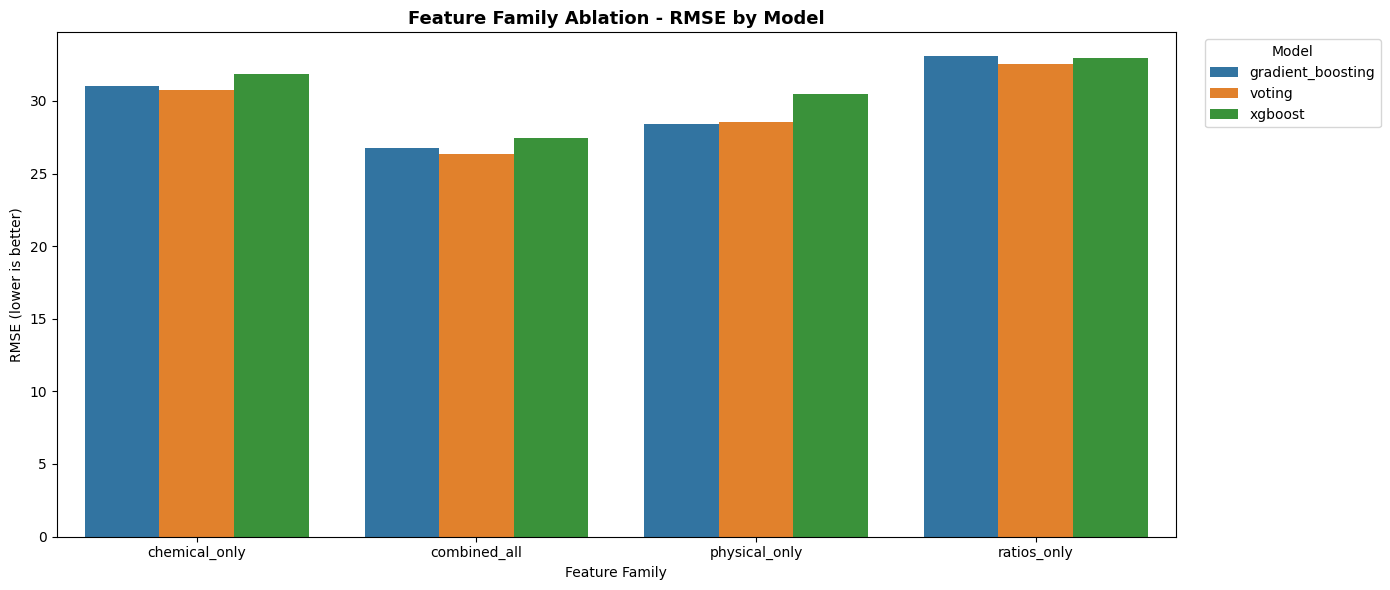

Saved: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\12_ablation_feature_families_no_scripts\outputs\summary\figures\ablation_rmse_by_feature_family.png


,feature_family,model_name,rmse,r2
2,chemical_only,gradient_boosting,31.133319,-49.378929
11,combined_all,gradient_boosting,27.723086,-6.876910
20,physical_only,gradient_boosting,29.398512,-4.345372
32,ratios_only,voting,34.164014,-59.617126


In [4]:
plot_df = summary.copy()
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=plot_df,
    x='feature_family',
    y='rmse',
    hue='model_name',
    ax=ax,
    errorbar=None
)
ax.set_title('Feature Family Ablation - RMSE by Model', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Family')
ax.set_ylabel('RMSE (lower is better)')
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

fig_path = SUMMARY_FIG_ROOT / 'ablation_rmse_by_feature_family.png'
fig.savefig(fig_path, dpi=600, bbox_inches='tight')
plt.show()
print('Saved:', fig_path)

best_spatial = summary[summary['protocol'] == 'spatial_holdout'].sort_values(['feature_family', 'rmse'])
best_spatial.groupby('feature_family').head(1)[['feature_family', 'model_name', 'rmse', 'r2']]

### Execution Notes

1. Start by running all code cells in order.
2. Confirm `feature_map` counts are non-zero for each family; if one is zero, adjust naming logic in the setup cell.
3. Use `outputs/summary/tables/protocol_summary_feature_family_ablation.csv` for model comparison with RMSE and R2.
4. Use `outputs/summary/tables/best_model_per_feature_family.csv` for deployment candidate selection.
5. Prioritize `spatial_holdout` RMSE and R2 when selecting final models.